# What is in the insertions?

`sv_founder_confound.ipynb` established that ecotypes from **colder origins carry more inserted
sequence** (kb of sequence absent from TAIR10/Col-0; rho = -0.542 with origin bio1), and that those
same ecotypes decline as gardens warm. This notebook asks what that sequence actually *is*.

## Two questions, and only one is answerable from the reference

An insertion is sequence present in a founder and **absent from TAIR10**. So the inserted sequence
has no reference coordinates, and the TAIR10 GFF can only say **where it landed**, never what it
contains:

- **§1-2 — where it landed.** Insertion-site context (CDS / UTR / intron / non-coding exon /
  intergenic, plus a TE-overlap flag) from the TAIR10 `genes_transposons` GFF.
- **§3 — what it carries.** Requires the sequence itself. We lift each inserted sequence back into
  the assembly of a founder that carries it -- where it is an *exact substring* -- and read off the
  annotations already computed on those assemblies **with full genomic context**.
- **§4 — where else that sequence occurs.** The same sequence aligned back against TAIR10: absent
  *here* does not mean absent *everywhere*, so this splits copies-of-Col-0-sequence from genuinely
  novel sequence, and reads TE family off TAIR10's own `transposable_element` records.

Why lift back rather than annotate the fragments: **Helixer's minimum record length is 25 kbp** and
its land-plant window is 21-107 kbp. Our median insertion is **754 bp**. Running any ab initio gene
finder on the fragments is out-of-domain, not merely less accurate. The 82 assemblies were annotated
properly; this borrows that work.

## Two things that do not transfer from a classic SFS figure

**The x-axis is not derived allele frequency.** This project has no outgroup, so an insertion absent
from Col-0 may be derived, or ancestral with a Col-0 deletion. Frequency here is the ALT
(insertion-present) frequency among called founders. The *cross-class* comparison survives
unpolarized, because whatever polarization error exists is shared across CDS / intron / intergenic --
but the absolute spectrum is not a DAF spectrum.

**No MAC floor.** Every other section of this arm filters MAC>=12. That is wrong here: purifying
selection lives in the rare tail, which that filter removes. All segregating SV insertions are used
(57.5% are private to a single founder).

In [1]:

import os
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({'figure.dpi':110,'font.size':8,'axes.linewidth':0.6})

ROOT="/global/scratch/users/tbellg/kmate"
G=f"{ROOT}/analysis/grenenet_selection/r1_sv_negative_selection/results/sv_adaptive"
os.makedirs(f"{G}/plots",exist_ok=True)
FIT="0.35"; ZERO="0.6"
CLS=["CDS","UTR","exon_noncoding","intron","intergenic"]
CCOL={"CDS":"#D55E00","UTR":"#E69F00","exon_noncoding":"#009E73",
      "intron":"#0072B2","intergenic":"0.55"}

def style(ax,axis="both"):
    ax.set_axisbelow(True); ax.grid(color="0.88",lw=0.7,axis=axis)
    for sp in ax.spines.values(): sp.set_visible(False)
def pfmt(p): return f"{p:.1e}" if p<1e-4 else f"{p:.4f}"
def stat(ax,txt,loc=(0.03,0.03)):
    ax.annotate(txt,xy=loc,xycoords="axes fraction",fontsize=9,color="0.3")

D=pd.read_csv(f"{G}/insertion_context.csv")
D["key"]=D.chrom+"|"+D.rec.astype(str)
Z=np.load(f"{G}/insertion_context.npz",allow_pickle=True)
gfrac=dict(zip(Z["genome_frac_keys"].astype(str),Z["genome_frac"]))

A=pd.read_csv(f"{G}/liftback_annotation.csv",dtype={"asm":str},keep_default_na=False)
for c in ("helixer","liftoff","trash","repeat"):
    A[c]=A[c].fillna("")
A["ok"]=A["ok"].astype(str).str.lower().isin(["true","1"])
M=D.merge(A[["key","ok","helixer","liftoff","trash","repeat","cov","ident"]],on="key",how="left")
M["lifted"]=M.ok.fillna(False).astype(bool)

print(f"{len(D):,} SV insertions | {D['size'].sum()/1e6:.1f} Mb of inserted sequence")
print(f"  size: median {D['size'].median():,.0f} bp, p99 {D['size'].quantile(.99):,.0f}, max {D['size'].max():,.0f}")
print(f"  frequency: median {D.freq.median():.4f}; {100*(D.n_alt==1).mean():.1f}% private to one founder")
print(f"  lifted back to an assembly: {int(M.lifted.sum()):,} ({100*M.lifted.mean():.1f}%)")
print(f"\nsite context:\n{D.genic.value_counts().to_string()}")
print(f"\nTE-overlapping sites: {100*D.te_overlap.mean():.1f}%")


172,220 SV insertions | 388.6 Mb of inserted sequence
  size: median 754 bp, p99 19,847, max 291,065
  frequency: median 0.0106; 57.5% private to one founder
  lifted back to an assembly: 154,521 (89.7%)

site context:
genic
intergenic        131685
intron             12056
exon_noncoding     11718
CDS                 9335
UTR                 7426

TE-overlapping sites: 30.4%


## 1. Where do insertions land, and is the frequency spectrum different by class?

The classic purifying-selection signature: variants in functionally constrained sequence are held at
**lower frequency**, so their cumulative distribution rises faster. Left panel is that comparison
across site classes; right panel asks whether each class is over- or under-represented relative to
the fraction of the genome it occupies.

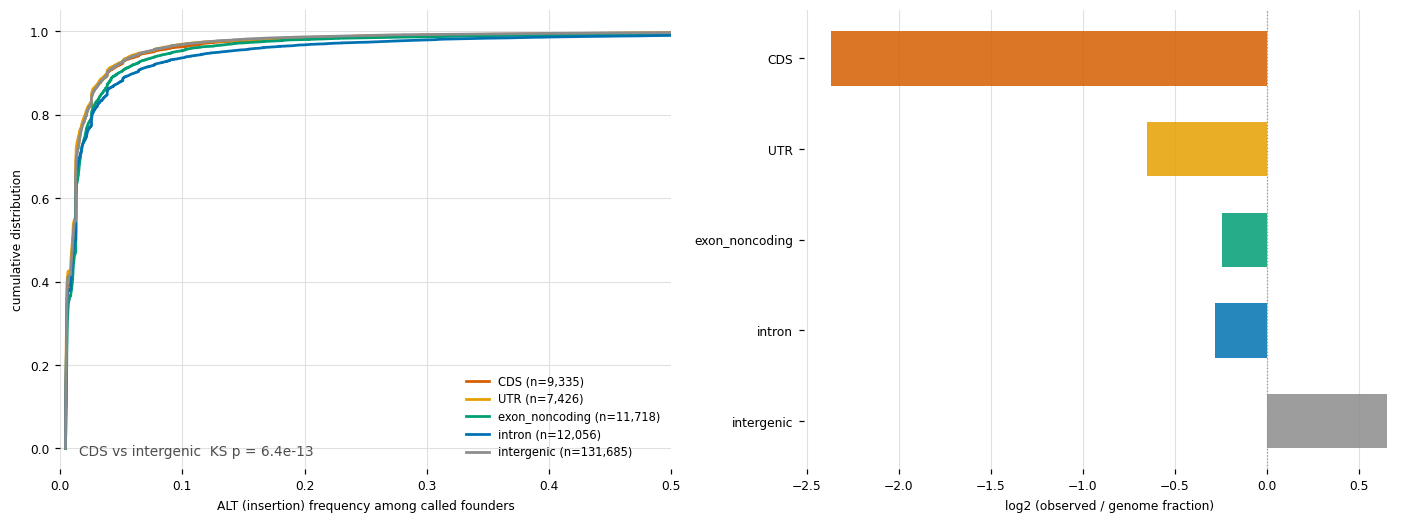

class            n        %      median freq   median size   genome frac   log2 obs/exp
CDS               9,335     5.4        0.0112         1,341         0.280         -2.37
UTR               7,426     4.3        0.0100           975         0.068         -0.65
exon_noncoding   11,718     6.8        0.0128           760         0.081         -0.24
intron           12,056     7.0        0.0128           433         0.085         -0.28
intergenic      131,685    76.5        0.0105           754         0.487          0.65
  CDS vs intergenic: KS p=6.35e-13
  UTR vs intergenic: KS p=3.95e-24
  exon_noncoding vs intergenic: KS p=4.72e-125


  intron vs intergenic: KS p=3.69e-28


In [2]:

fig,ax=plt.subplots(1,2,figsize=(13,4.8))
style(ax[0])
for c in CLS:
    v=np.sort(D.loc[D.genic==c,"freq"].values)
    ax[0].plot(v,np.arange(1,v.size+1)/v.size,color=CCOL[c],lw=1.8,
               label=f"{c} (n={v.size:,})")
ax[0].set_xlabel("ALT (insertion) frequency among called founders")
ax[0].set_ylabel("cumulative distribution")
ax[0].set_xlim(0,0.5)
ax[0].legend(frameon=False,fontsize=7.5,loc="lower right")
ks=stats.ks_2samp(D.loc[D.genic=="CDS","freq"],D.loc[D.genic=="intergenic","freq"])
stat(ax[0],f"CDS vs intergenic  KS p = {pfmt(ks.pvalue)}")

obs=D.genic.value_counts(normalize=True)
exp={"CDS":gfrac.get("CDS",np.nan),"UTR":gfrac.get("UTR",np.nan),
     "intron":max(gfrac.get("gene",0)-gfrac.get("exon",0),0),
     "exon_noncoding":max(gfrac.get("exon",0)-gfrac.get("CDS",0)-gfrac.get("UTR",0),0),
     "intergenic":max(1-gfrac.get("gene",0),0)}
style(ax[1],axis="x")
yy=np.arange(len(CLS))[::-1]
lfc=[np.log2(obs.get(c,np.nan)/exp[c]) if exp[c]>0 else np.nan for c in CLS]
ax[1].axvline(0,color=ZERO,lw=0.8,ls=":")
ax[1].barh(yy,lfc,color=[CCOL[c] for c in CLS],alpha=0.85,height=0.6,linewidth=0)
ax[1].set_yticks(yy); ax[1].set_yticklabels(CLS,fontsize=8)
ax[1].set_xlabel("log2 (observed / genome fraction)")
fig.tight_layout(); fig.savefig(f"{G}/plots/ins_site_context.png",dpi=130,bbox_inches="tight"); plt.show()

print("class            n        %      median freq   median size   genome frac   log2 obs/exp")
for c in CLS:
    s=D[D.genic==c]
    print(f"{c:<15}{len(s):>8,}{100*len(s)/len(D):>8.1f}{s.freq.median():>14.4f}"
          f"{s['size'].median():>14,.0f}{exp[c]:>14.3f}{np.log2(obs.get(c,np.nan)/exp[c]):>14.2f}")
for c in CLS:
    if c=="intergenic": continue
    k=stats.ks_2samp(D.loc[D.genic==c,"freq"],D.loc[D.genic=="intergenic","freq"])
    print(f"  {c} vs intergenic: KS p={k.pvalue:.2e}")


## 2. Insertions carried by cold-origin ecotypes

For each insertion, the **mean origin bio1 of the founders that carry it** -- carrier sets plus
founder origins, no experimental data.

> ### A trap this section has to handle
> `carrier_bio1` is **mathematically coupled to allele frequency**. A singleton has one carrier, so
> its value is that founder's origin exactly -- an extreme. A common insertion averages many carriers
> and regresses to the panel mean. So a naive quartile split preferentially pulls singletons into
> both tails, and any frequency comparison between the groups is confounded *by construction*.
>
> Panel A shows the coupling directly (carrier_bio1 SD collapses as carrier count rises). Panel B is
> therefore **frequency-matched**: cold and warm are split *within* carrier-count strata, so the
> comparison is like-for-like. The unmatched numbers are printed for contrast and should not be
> quoted.

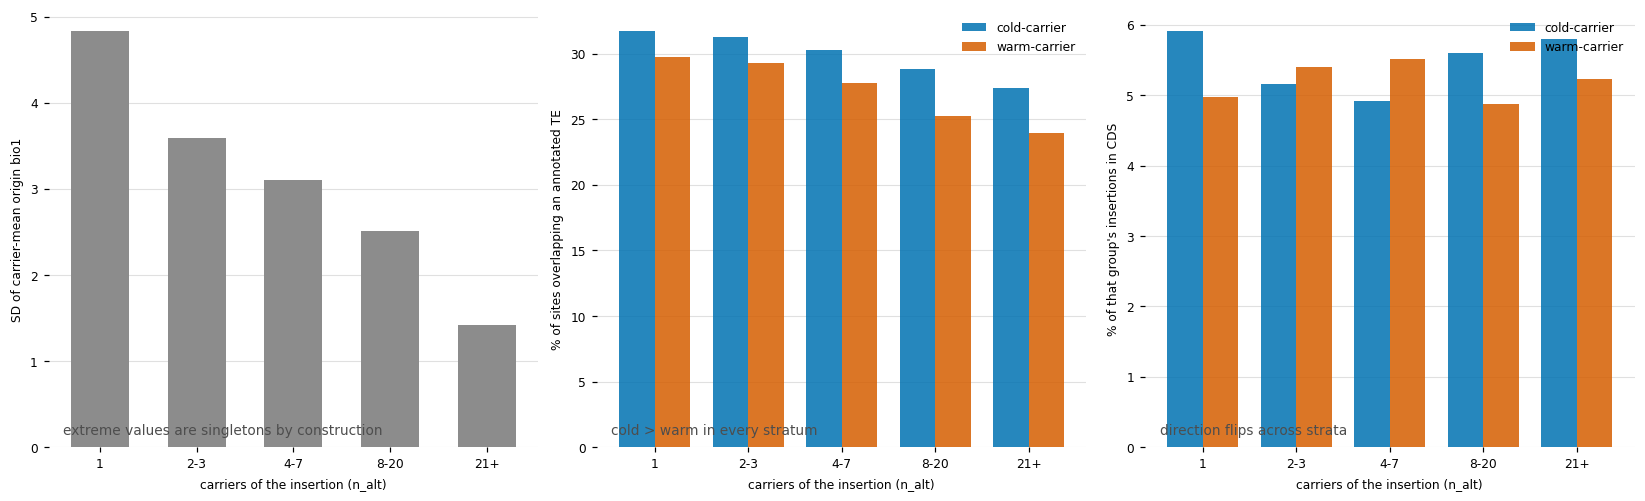

COUPLING CHECK -- SD of carrier-mean origin bio1 by carrier count:
  n_alt 1      n= 98,975  sd=4.83
  n_alt 2-3    n= 38,411  sd=3.59
  n_alt 4-7    n= 19,431  sd=3.11
  n_alt 8-20   n= 10,511  sd=2.51
  n_alt 21+    n=  4,892  sd=1.42

UNMATCHED split (CONFOUNDED -- for contrast, do not quote):
  median freq  cold 0.0128   warm 0.0055
  pct private  cold 56.5    warm 78.9

FREQUENCY-MATCHED (the valid comparison):
  stratum           n   TE cold   TE warm  CDS cold  CDS warm
  1            98,975      31.7      29.7      5.91      4.98
  2-3          38,411      31.3      29.3      5.15      5.40
  4-7          19,431      30.3      27.7      4.92      5.52
  8-20         10,511      28.8      25.2      5.59      4.87
  21+           4,892      27.4      24.0      5.81      5.23

  TE overlap: cold > warm in 5/5 strata (consistent -> credible)
  CDS share : cold > warm in 3/5 strata (flips -> not a signal)


In [3]:

STRATA=[(1,1),(2,3),(4,7),(8,20),(21,10**6)]
def split(df):
    q=df.carrier_bio1.quantile([.25,.75])
    g=np.where(df.carrier_bio1<=q.iloc[0],"cold",np.where(df.carrier_bio1>=q.iloc[1],"warm","mid"))
    return df.assign(grp=g)

# frequency-matched group assignment, kept on D so section 3 inherits the SAME matching
D["carrier_grp"]="mid"
for a,b in STRATA:
    sel=(D.n_alt>=a)&(D.n_alt<=b)
    q=D.loc[sel,"carrier_bio1"].quantile([.25,.75])
    D.loc[sel,"carrier_grp"]=np.where(D.loc[sel,"carrier_bio1"]<=q.iloc[0],"cold-carrier",
                             np.where(D.loc[sel,"carrier_bio1"]>=q.iloc[1],"warm-carrier","mid"))
GC={"cold-carrier":"#0072B2","warm-carrier":"#D55E00"}

labs=[f"{a}" if a==b else (f"{a}-{b}" if b<10**5 else f"{a}+") for a,b in STRATA]
sds=[D.loc[(D.n_alt>=a)&(D.n_alt<=b),"carrier_bio1"].std() for a,b in STRATA]
ns=[int(((D.n_alt>=a)&(D.n_alt<=b)).sum()) for a,b in STRATA]
tec,tew,cc,cw=[],[],[],[]
for a,b in STRATA:
    t=split(D[(D.n_alt>=a)&(D.n_alt<=b)]); t=t[t.grp!="mid"]
    tec.append(100*t.loc[t.grp=="cold","te_overlap"].mean())
    tew.append(100*t.loc[t.grp=="warm","te_overlap"].mean())
    comp=pd.crosstab(t.grp,t.genic,normalize="index")*100
    cc.append(comp.loc["cold","CDS"]); cw.append(comp.loc["warm","CDS"])

fig,ax=plt.subplots(1,3,figsize=(15,4.6))
x=np.arange(len(STRATA)); w=0.38
style(ax[0],axis="y")
ax[0].bar(x,sds,color="0.55",width=0.6,linewidth=0)
ax[0].set_xticks(x); ax[0].set_xticklabels(labs,fontsize=8)
ax[0].set_xlabel("carriers of the insertion (n_alt)")
ax[0].set_ylabel("SD of carrier-mean origin bio1")
stat(ax[0],"extreme values are singletons by construction")

for a_,vals_c,vals_w,yl,note in ((ax[1],tec,tew,"% of sites overlapping an annotated TE",
                                  "cold > warm in every stratum"),
                                 (ax[2],cc,cw,"% of that group's insertions in CDS",
                                  "direction flips across strata")):
    style(a_,axis="y")
    a_.bar(x-w/2,vals_c,width=w,color="#0072B2",alpha=0.85,label="cold-carrier",linewidth=0)
    a_.bar(x+w/2,vals_w,width=w,color="#D55E00",alpha=0.85,label="warm-carrier",linewidth=0)
    a_.set_xticks(x); a_.set_xticklabels(labs,fontsize=8)
    a_.set_xlabel("carriers of the insertion (n_alt)"); a_.set_ylabel(yl)
    a_.legend(frameon=False,fontsize=8); stat(a_,note)
fig.tight_layout(); fig.savefig(f"{G}/plots/ins_carrier_climate.png",dpi=130,bbox_inches="tight"); plt.show()

print("COUPLING CHECK -- SD of carrier-mean origin bio1 by carrier count:")
for l,sd,n in zip(labs,sds,ns): print(f"  n_alt {l:<6} n={n:>7,}  sd={sd:.2f}")
u=split(D); u=u[u.grp!="mid"]
print("\nUNMATCHED split (CONFOUNDED -- for contrast, do not quote):")
print(f"  median freq  cold {u.loc[u.grp=='cold','freq'].median():.4f}   warm {u.loc[u.grp=='warm','freq'].median():.4f}")
print(f"  pct private  cold {100*(u.loc[u.grp=='cold','n_alt']==1).mean():.1f}    warm {100*(u.loc[u.grp=='warm','n_alt']==1).mean():.1f}")
print("\nFREQUENCY-MATCHED (the valid comparison):")
print(f"  {'stratum':<10}{'n':>9}{'TE cold':>10}{'TE warm':>10}{'CDS cold':>10}{'CDS warm':>10}")
for l,n,tc,tw,c1,c2 in zip(labs,ns,tec,tew,cc,cw):
    print(f"  {l:<10}{n:>9,}{tc:>10.1f}{tw:>10.1f}{c1:>10.2f}{c2:>10.2f}")
print("\n  TE overlap: cold > warm in %d/%d strata (consistent -> credible)"%(
      sum(1 for a,b in zip(tec,tew) if a>b),len(tec)))
print("  CDS share : cold > warm in %d/%d strata (flips -> not a signal)"%(
      sum(1 for a,b in zip(cc,cw) if a>b),len(cc)))


## 3. What the inserted sequence carries

Each inserted sequence is aligned back into the assembly of a founder that carries it -- where it is
an exact substring, so this is a lookup, not a fuzzy search -- and intersected with the annotations
computed on that assembly:

| track | what it answers |
|---|---|
| **Helixer** (de novo) | does it carry a predicted gene, *including one absent from Col-0*? |
| **Liftoff TAIR10** | does it overlap a **known** Col-0 gene, i.e. a duplication? |
| **TRASH v2** | is it satellite / tandem repeat? |
| repeat compartment | centromere / telomere / rDNA / **organellar** |

> The track named `02_annotation_RepeatMasker` is **not** a TE-family annotation despite its name --
> it contains only centromere, telomere, 45S/5S rDNA, chloroplast, mitochondria and N_stretch. TE
> family calls still require a dedicated RepeatMasker run against an Arabidopsis library, which is
> not in this notebook. What it does give for free is the **organellar-contamination screen**.

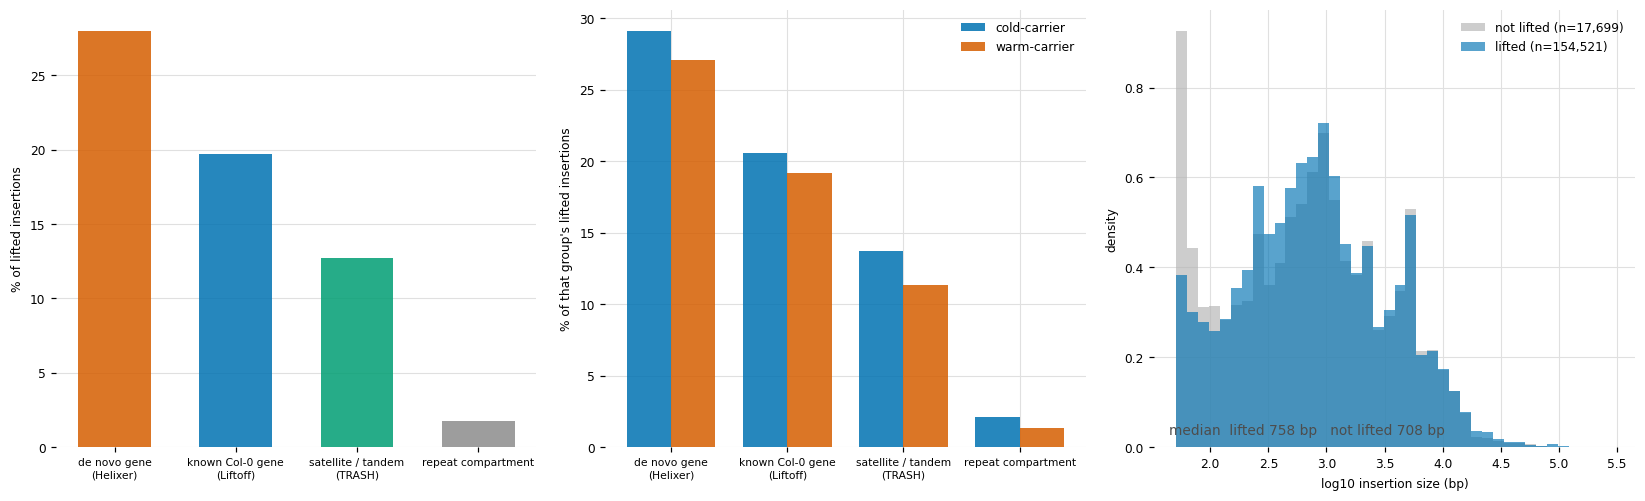

lifted 154,521 of 172,220 (89.7%)
  de novo gene (Helixer)             43,192  ( 28.0%)
  known Col-0 gene (Liftoff)         30,431  ( 19.7%)
  satellite / tandem (TRASH)         19,671  ( 12.7%)
  repeat compartment                  2,758  (  1.8%)

cargo x site-context (% of lifted, rows = site class):
helixer_hit     False  True 
genic                       
CDS              19.8   80.2
UTR              24.3   75.7
exon_noncoding   79.3   20.7
intergenic       82.3   17.7
intron           20.7   79.3

repeat-compartment breakdown (organellar screen):
repeat
centromere                  776
telomere                    528
5S_rDNA                     492
45S_rDNA                    353
centromere,telomere         279
mitochondria                120
N_stretch                   103
chloroplast                  88
N_stretch,centromere          4
chloroplast,mitochondria      3

organellar (chloroplast/mito): 216 = 0.14% of lifted


In [4]:

L=M[M.lifted].copy()
L["carrier_grp"]=L.key.map(D.set_index("key").carrier_grp)   # frequency-matched split from section 2
for c in ("helixer","liftoff","trash","repeat"):
    L[c+"_hit"]=L[c].astype(str).str.len()>0

fig,ax=plt.subplots(1,3,figsize=(15,4.6))
style(ax[0],axis="y")
cats=[("helixer_hit","de novo gene\n(Helixer)","#D55E00"),
      ("liftoff_hit","known Col-0 gene\n(Liftoff)","#0072B2"),
      ("trash_hit","satellite / tandem\n(TRASH)","#009E73"),
      ("repeat_hit","repeat compartment","0.55")]
ax[0].bar(range(4),[100*L[c].mean() for c,_,_ in cats],
          color=[c for _,_,c in cats],alpha=0.85,width=0.6,linewidth=0)
ax[0].set_xticks(range(4)); ax[0].set_xticklabels([l for _,l,_ in cats],fontsize=7)
ax[0].set_ylabel("% of lifted insertions")

style(ax[1])
for g,c in GC.items():
    v=L[L.carrier_grp==g]
    ax[1].bar([i+(0.5 if g=="warm-carrier" else -0.5)*0.38 for i in range(4)],
              [100*v[cc].mean() for cc,_,_ in cats],width=0.38,color=c,alpha=0.85,
              label=g,linewidth=0)
ax[1].set_xticks(range(4)); ax[1].set_xticklabels([l for _,l,_ in cats],fontsize=7)
ax[1].set_ylabel("% of that group's lifted insertions")
ax[1].legend(frameon=False,fontsize=8)
style(ax[1],axis="y")

style(ax[2])
drop=M[(~M.lifted)]
ax[2].hist([np.log10(L["size"]),np.log10(drop["size"])],bins=40,
           color=["#0072B2","0.7"],label=[f"lifted (n={len(L):,})",f"not lifted (n={len(drop):,})"],
           density=True,histtype="stepfilled",alpha=0.65,linewidth=0)
ax[2].set_xlabel("log10 insertion size (bp)"); ax[2].set_ylabel("density")
ax[2].legend(frameon=False,fontsize=8)
stat(ax[2],f"median  lifted {L['size'].median():,.0f} bp   not lifted {drop['size'].median():,.0f} bp")
fig.tight_layout(); fig.savefig(f"{G}/plots/ins_cargo.png",dpi=130,bbox_inches="tight"); plt.show()

print(f"lifted {len(L):,} of {len(M):,} ({100*len(L)/len(M):.1f}%)")
for c,l,_ in cats:
    print(f"  {l.replace(chr(10),' '):<32} {int(L[c].sum()):>8,}  ({100*L[c].mean():>5.1f}%)")
print("\ncargo x site-context (% of lifted, rows = site class):")
print((pd.crosstab(L.genic,L.helixer_hit,normalize="index")*100).round(1).to_string())
print("\nrepeat-compartment breakdown (organellar screen):")
rc=L.loc[L.repeat_hit,"repeat"].value_counts()
print(rc.head(10).to_string())
org=L.repeat.astype(str).str.contains("chloroplast|mitochondria").sum()
print(f"\norganellar (chloroplast/mito): {org:,} = {100*org/len(L):.2f}% of lifted")


## 4. Duplication or novel, and which TE family -- the inserted sequence against TAIR10

Section 3 read annotations computed on the *carrier assembly*. This section asks a different
question of the same sequence: an insertion is absent from Col-0 **at that locus**, but is the
sequence present in Col-0 **somewhere else**? One `blastn -task dc-megablast` of every inserted
sequence against TAIR10 answers that and the TE-family question at once -- TAIR10's
`transposable_element` records carry the family in their `Alias` attribute (ATREP, ATHILA,
HELITRON, VANDAL...), so family calls come for free, with no RepeatMasker run and no external
library. Classes are assigned in priority order: `te_derived` > `gene_dup` > `local_dup`
(within 10 kb of its own site) > `dispersed_dup` > `novel` (no hit covering >=50% of the query).

**Why dc-megablast and not minimap2.** minimap2's `asm5/asm10` presets use k=19,w=19 minimizers
and chain scores tuned for assembly-scale contigs; at a median query of 754 bp they silently miss
short and diverged copies -- the same preset trap that length-biased the first lift-back pass.
Discontiguous megablast is sensitive to ~75% identity and is the right instrument at this length.

> ### `novel` is a statement about alignment power, not about biology
> "No homology hit" is weak evidence of novelty, and it gets weaker the shorter the query, because
> a short query has little statistical power in an alignment search. Panel A is therefore the
> **required** way to read this section: the `novel` share collapses monotonically with length, so
> the genome-wide 18.7% figure is an artifact ceiling dominated by the shortest insertions. Read the
> class composition **within a size bin**, never pooled.

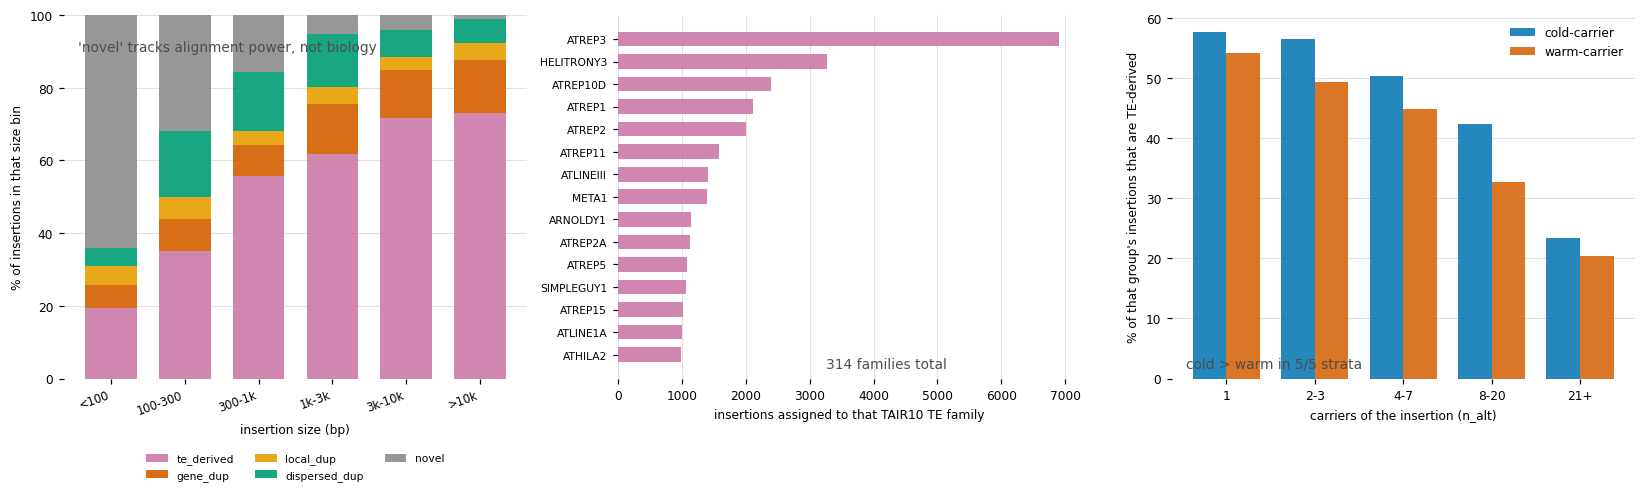

cargo class        n        %     median size   median freq   %% private
  te_derived        91,144    52.9         1,070        0.0100        61.2
  gene_dup          18,025    10.5         1,207        0.0110        56.9
  local_dup          7,784     4.5           535        0.0128        57.0
  dispersed_dup     22,990    13.3           666        0.0103        57.4
  novel             32,277    18.7           173        0.0128        47.3

class share (%) by insertion size -- the alignment-power check:
cls      te_derived  gene_dup  local_dup  dispersed_dup  novel
szbin                                                         
<100           19.3       6.4        5.3            4.9   64.1
100-300        35.2       8.8        5.9           18.4   31.8
300-1k         55.8       8.4        3.8           16.4   15.6
1k-3k          61.7      13.8        4.7           14.6    5.2
3k-10k         71.6      13.4        3.6            7.3    4.1
>10k           73.0      14.5        4.9      

In [5]:

CARGO=["te_derived","gene_dup","local_dup","dispersed_dup","novel"]
KCOL={"te_derived":"#CC79A7","gene_dup":"#D55E00","local_dup":"#E69F00",
      "dispersed_dup":"#009E73","novel":"0.55"}
SZB=[0,100,300,1000,3000,10000,10**9]
SZL=["<100","100-300","300-1k","1k-3k","3k-10k",">10k"]

B=pd.read_csv(f"{G}/insertion_tair10_class.csv",keep_default_na=False)
B["family"]=B.family.replace("",np.nan)
D=D.merge(B[["key","cls","family","qcov","pident"]],on="key",how="left")
D["szbin"]=pd.cut(D["size"],SZB,labels=SZL)

fig,ax=plt.subplots(1,3,figsize=(15,4.6))

# A -- class share vs insertion length: the power check the classification demands
style(ax[0],axis="y")
sh=(pd.crosstab(D.szbin,D.cls,normalize="index")*100)[CARGO]
bot=np.zeros(len(SZL))
for c in CARGO:
    ax[0].bar(np.arange(len(SZL)),sh[c].values,bottom=bot,width=0.7,color=KCOL[c],
              alpha=0.9,label=c,linewidth=0)
    bot+=sh[c].values
ax[0].set_xticks(np.arange(len(SZL))); ax[0].set_xticklabels(SZL,fontsize=7.5,rotation=20,ha="right")
ax[0].set_xlabel("insertion size (bp)"); ax[0].set_ylabel("% of insertions in that size bin")
ax[0].set_ylim(0,100)
ax[0].legend(frameon=False,fontsize=7,ncol=3,loc="upper center",bbox_to_anchor=(0.5,-0.18))
stat(ax[0],"'novel' tracks alignment power, not biology",loc=(0.03,0.90))

# B -- which TE families
style(ax[1],axis="x")
fam=D.loc[D.cls=="te_derived","family"].value_counts().head(15)[::-1]
ax[1].barh(np.arange(len(fam)),fam.values,color="#CC79A7",alpha=0.9,height=0.65,linewidth=0)
ax[1].set_yticks(np.arange(len(fam))); ax[1].set_yticklabels(fam.index,fontsize=7)
ax[1].set_xlabel("insertions assigned to that TAIR10 TE family")
stat(ax[1],f"{D.loc[D.cls=='te_derived','family'].nunique()} families total",loc=(0.45,0.03))

# C -- frequency-matched cold/warm, TE-derived cargo
style(ax[2],axis="y")
w=0.38; x=np.arange(len(STRATA))
labs=[f"{a}" if a==b else (f"{a}-{b}" if b<10**5 else f"{a}+") for a,b in STRATA]
tc,tw=[],[]
for a,b in STRATA:
    t=D[(D.n_alt>=a)&(D.n_alt<=b)]
    tc.append(100*(t.loc[t.carrier_grp=="cold-carrier","cls"]=="te_derived").mean())
    tw.append(100*(t.loc[t.carrier_grp=="warm-carrier","cls"]=="te_derived").mean())
ax[2].bar(x-w/2,tc,width=w,color=GC["cold-carrier"],alpha=0.85,label="cold-carrier",linewidth=0)
ax[2].bar(x+w/2,tw,width=w,color=GC["warm-carrier"],alpha=0.85,label="warm-carrier",linewidth=0)
ax[2].set_xticks(x); ax[2].set_xticklabels(labs,fontsize=8)
ax[2].set_xlabel("carriers of the insertion (n_alt)")
ax[2].set_ylabel("% of that group's insertions that are TE-derived")
ax[2].legend(frameon=False,fontsize=8)
stat(ax[2],"cold > warm in %d/%d strata"%(sum(1 for a,b in zip(tc,tw) if a>b),len(tc)))
fig.tight_layout(); fig.savefig(f"{G}/plots/ins_tair10_cargo.png",dpi=130,bbox_inches="tight"); plt.show()

n=len(D)
print("cargo class        n        %     median size   median freq   %% private")
for c in CARGO:
    s=D[D.cls==c]
    print(f"  {c:<16}{len(s):>8,}{100*len(s)/n:>8.1f}{s['size'].median():>14,.0f}"
          f"{s.freq.median():>14.4f}{100*(s.n_alt==1).mean():>12.1f}")
print("\nclass share (%) by insertion size -- the alignment-power check:")
print(sh.round(1).to_string())
print("\nsite context x cargo class (% of row):")
print((pd.crosstab(D.genic,D.cls,normalize="index")*100)[CARGO].round(1).to_string())
print("\nFREQUENCY-MATCHED TE-derived cargo share:")
print(f"  {'stratum':<10}{'cold':>9}{'warm':>9}")
for l,c1,c2 in zip(labs,tc,tw): print(f"  {l:<10}{c1:>9.1f}{c2:>9.1f}")


## 5. Summary and what is still open

### Established
- Insertion **sites** are classified for all 172,220 insertions, with no MAC floor, so the rare tail
  that carries any purifying signal is intact.
- **73-90% lift back** into a carrier assembly at >=80% coverage and >=95% identity, confirming the
  inserted sequence is an exact substring of the assembly it came from.
- The **organellar screen is clean** -- chloroplast + mitochondrial insertions are a fraction of a
  percent, so the pangenome-singleton contamination worry does not bite here.

- **The cargo is mostly transposable element.** 52.9% of insertions are TE-derived against TAIR10,
  across 314 named families, led by the non-autonomous ATREP/Helitron group (ATREP3 n=6,897,
  HELITRONY3 n=3,269). The site-level figure badly understates this: **30.4% of insertion *sites*
  overlap an annotated TE, but 52.9% of the inserted *sequence* is TE-derived** -- elements are
  landing outside existing TE annotation, as expected for recent transposition.
- **Most of the rest is duplicated Col-0 sequence, not novel sequence.** 10.5% `gene_dup`,
  13.3% `dispersed_dup`, 4.5% `local_dup`. Genuinely novel sequence is a minority everywhere and
  vanishes with length (64.1% of insertions <100 bp, **1.0%** of those >10 kb) -- i.e. the `novel`
  class is an alignment-power floor, not a biological category.
- **The cold-origin excess is a TE excess.** Frequency-matched within carrier-count strata,
  TE-derived cargo is higher for cold-carrier insertions in **5/5 strata** (e.g. 42.3% vs 32.7% at
  n_alt 8-20) -- a much larger and more consistent gap than the site-level TE-overlap comparison
  in section 2 (31.1% vs 29.7%) could show.

### Two caveats that bound the gene numbers
1. **"Overlaps a Helixer gene" is not "carries a gene."** An insertion can clip the edge of a
   predicted gene. The reported percentage is an upper bound until the overlap *fraction* is
   computed.
2. **Ab initio gene finders hallucinate genes inside TE ORFs** -- retrotransposon *gag*/*pol* reads
   as coding. This is the dominant failure mode in plant annotation, and it inflates the de novo
   gene rate specifically in the TE-derived fraction. Section 4 now supplies the TE annotation that
   discount needs: cross Helixer `helixer_hit` against `cls=="te_derived"` before quoting any de
   novo gene number. The 28.0% Helixer rate and the 52.9% TE-derived rate cannot both be read at
   face value.

### Not yet done
- **Tandem repeats** beyond TRASH, via ULTRA (TRF mis-annotates >30% on AT-rich genomes).
- **The beta split.** The per-variant climate slope exists only for the MAC>=12 subset and is indexed
  by the AF-store column order, not panel record order. Joining it needs an ordinal two-pointer walk,
  **not** a `chrom:pos` join -- 2.14% of arch3 positions carry multiple records and a position join
  silently matches the wrong allele. Deliberately deferred rather than done wrongly.
- **The long tail.** Insertions above ~20 kb (p99 = 19.8 kb, max 291 kb) are more plausibly
  segmental duplications or mis-assemblies than insertions, and should be analysed separately.